In [1]:
import jax.numpy as jnp
from utils import load_run_data
import matplotlib.pyplot as plt
from notebooks.mail import email_pdf
# lstd_config, lstd_metrics = load_run_data("cov_lstd_ts/optimistic_episodic/", "DeepSea-bsuite", 'results')
# lstd_config_pess, lstd_metrics_pess = load_run_data("cov_lstd_ts/non_opt_episodic/", "DeepSea-bsuite", 'results')
lstd_config, lstd_metrics = load_run_data("cov_lstd_ts/optimistic_continuing/", "DeepSea-bsuite", 'results')
lstd_config_pess, lstd_metrics_pess = load_run_data("cov_lstd_ts/non_opt_continuing/", "DeepSea-bsuite", 'results')

# net_config, net_metrics = load_run_data("cov_net_v/episodic", "DeepSea-bsuite", 'results')
net_config, net_metrics = load_run_data("cov_net_v/continuing", "DeepSea-bsuite", 'results')


episodic_config, episodic_metrics = load_run_data('true_v/20260111_151930', "DeepSea-bsuite", 'results')
episodic_config_large, episodic_metrics_large = load_run_data('true_v/20260111_160215', "DeepSea-bsuite", 'results')
episodic_config_ema_N, episodic_metrics_ema_N = load_run_data('true_v/ema_N_b_small', "DeepSea-bsuite", 'results')
continuing_config, continuing_metrics = load_run_data('true_v/20260111_151910', "DeepSea-bsuite", 'results')
net_metrics.keys()

📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()


dict_keys(['bonus_max', 'bonus_mean', 'bonus_std', 'discount', 'e_value_error', 'e_value_loss', 'entropy', 'feat_norm', 'i_value_error', 'i_value_loss', 'intrinsic_rew_mean', 'intrinsic_rew_std', 'intrinsic_v_mean', 'intrinsic_v_std', 'lambda_ret_mean', 'lambda_ret_std', 'mean_rew', 'pi_loss', 'ppo_loss', 'returned_discounted_episode_returns', 'returned_episode', 'returned_episode_lengths', 'returned_episode_returns', 'v_e', 'v_e_pred', 'v_i', 'v_i_pred'])

In [2]:
N = lstd_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

In [3]:
reachable_mask[None,:].shape

(1, 20, 20)

Text(0.5, 1.0, 'Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

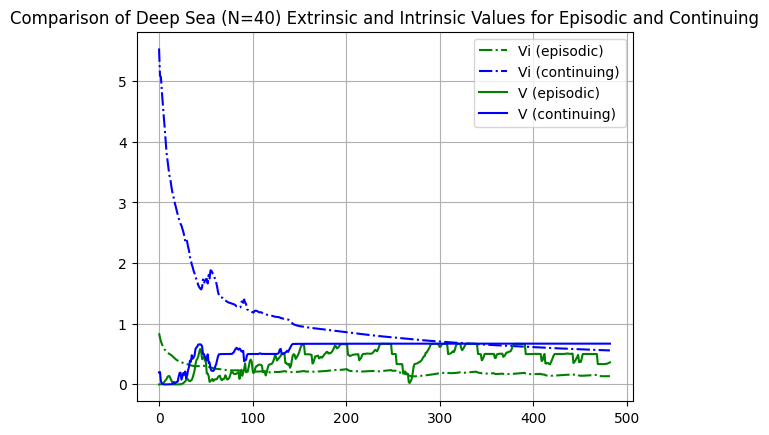

In [4]:
N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

# plt.plot(episodic_metrics['returned_episode_returns'].mean(0), label = 'Episodic Return')
# plt.plot(continuing_metrics['returned_episode_returns'].mean(0), label = 'Continuing Ret')
plt.plot((episodic_metrics['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (episodic)', color = 'green', ls = '-.')
plt.plot((continuing_metrics['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (continuing)', color = 'blue', ls = '-.')
plt.plot((episodic_metrics['v_e'].mean(0)[5:, 0,0]), label = 'V (episodic)', color = 'green', ls = '-')
plt.plot((continuing_metrics['v_e'].mean(0)[5:, 0,0]), label = 'V (continuing)', color = 'blue', ls = '-')
plt.legend()
plt.grid()
plt.title('Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

Text(0.5, 1.0, 'Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

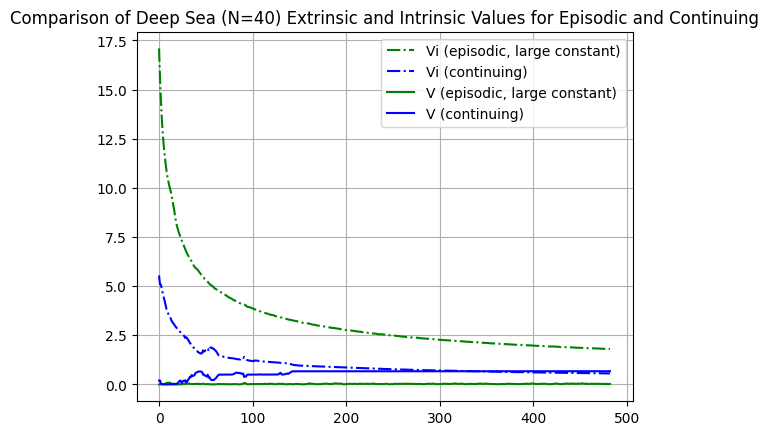

In [5]:
# plt.plot(episodic_metrics['returned_episode_returns'].mean(0), label = 'Episodic Return')
# plt.plot(continuing_metrics['returned_episode_returns'].mean(0), label = 'Continuing Ret')
plt.plot((episodic_metrics_large['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (episodic, large constant)', color = 'green', ls = '-.')
plt.plot((continuing_metrics['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (continuing)', color = 'blue', ls = '-.')
plt.plot((episodic_metrics_large['v_e'].mean(0)[5:, 0,0]), label = 'V (episodic, large constant)', color = 'green', ls = '-')
plt.plot((continuing_metrics['v_e'].mean(0)[5:, 0,0]), label = 'V (continuing)', color = 'blue', ls = '-')
plt.legend()
plt.grid()
plt.title('Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

Text(0.5, 1.0, 'Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

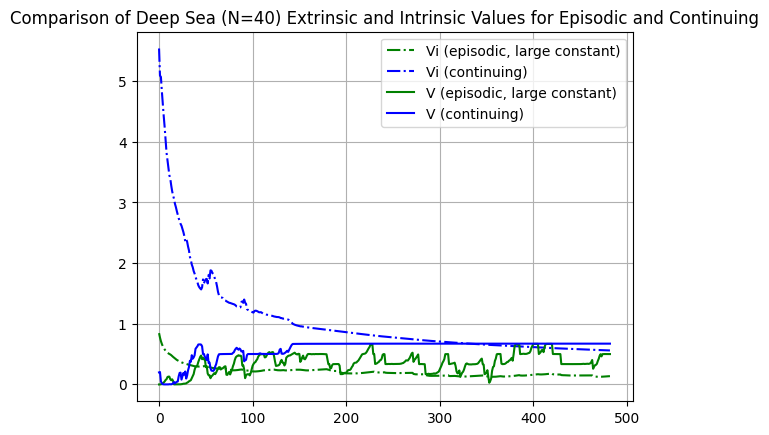

In [6]:
# plt.plot(episodic_metrics['returned_episode_returns'].mean(0), label = 'Episodic Return')
# plt.plot(continuing_metrics['returned_episode_returns'].mean(0), label = 'Continuing Ret')
plt.plot((episodic_metrics_ema_N['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (episodic, large constant)', color = 'green', ls = '-.')
plt.plot((continuing_metrics['v_i'].mean(0) * reachable_mask[None,:]).mean(-1).mean(-1)[5:], label = 'Vi (continuing)', color = 'blue', ls = '-.')
plt.plot((episodic_metrics_ema_N['v_e'].mean(0)[5:, 0,0]), label = 'V (episodic, large constant)', color = 'green', ls = '-')
plt.plot((continuing_metrics['v_e'].mean(0)[5:, 0,0]), label = 'V (continuing)', color = 'blue', ls = '-')
plt.legend()
plt.grid()
plt.title('Comparison of Deep Sea (N=40) Extrinsic and Intrinsic Values for Episodic and Continuing')

### Analysis: 
0. Show the extrinsic value function
1. plot intrinsic and exitrinsic value and predictions thereof
2. plot the absolute value error at the starting state for each.

## Extrinsic Value functions

In [7]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Extract Data
# initial_grid = metrics['v_e'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_e'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Extrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

In [8]:
# # 1. Extract Data
# initial_grid = metrics['v_i'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_i'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Intrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

In [9]:
# # 1. Extract Data
# initial_grid = metrics['v_i_pred'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_i_pred'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Intrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

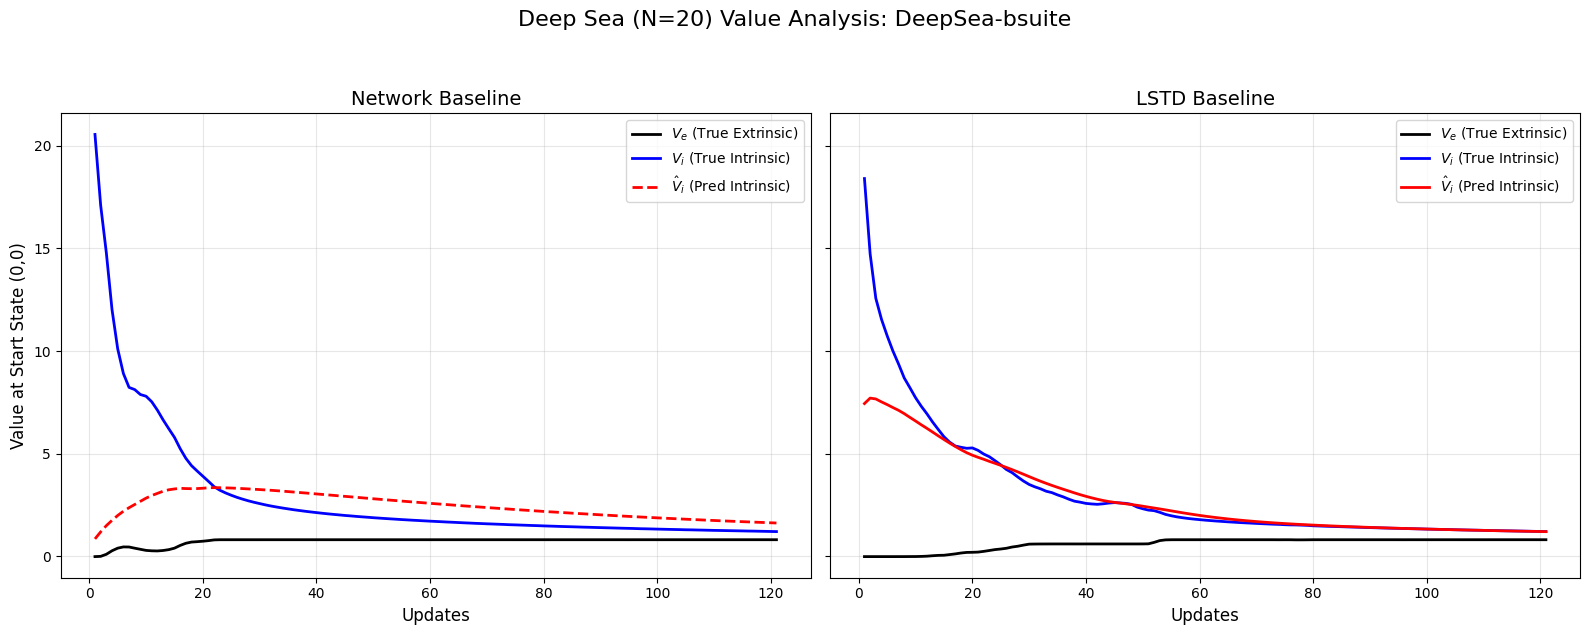

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def extract_start_state_curve(metric_data):
    """
    Helper to extract time-series for the start state (0,0).
    Handles (Time, N, N) or (Seeds, Time, N, N) shapes.
    """
    data = np.array(metric_data)
    
    # Handle Multi-seed: (Seeds, Time, ...) -> Mean over seeds -> (Time, ...)
    if data.ndim == 4: 
        data = data.mean(axis=0)
        
    # Handle Grid: (Time, N, N) -> Slice start state -> (Time,)
    if data.ndim == 3:
        return data[:, 0, 0]
    
    # Fallback if already scalar/1D
    return data

# --- Setup Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
run_data = [
    ("Network Baseline", net_metrics, axes[0]),
    ("LSTD Baseline", lstd_metrics, axes[1])
]

# Metrics to plot and their visual styles
# Keys match your dict: 'v_e', 'v_i_pred', 'v_i'
plot_config = [
    {"key": "v_e",      "label": r"$V_e$ (True Extrinsic)", "color": "black", "style": "-"},
    {"key": "v_i",      "label": r"$V_i$ (True Intrinsic)", "color": "blue",  "style": "-"},
    {"key": "v_i_pred", "label": r"$\hat{V}_i$ (Pred Intrinsic)", "color": "red",   "style": "--"},
    {"key": "fast_v_i_pred", "label": r"$\hat{V}_i$ (Pred Intrinsic)", "color": "red",   "style": "-"},
    # {"key": "slow_v_i_pred", "label": r"$\hat{V}_i$ (Pred i Pred)", "color": "red",   "style": "--"},
]

# --- Loop over Runs ---
for title, metrics, ax in run_data:
    for item in plot_config:
        key = item["key"]
        if key in metrics:
            # Extract curve
            curve = extract_start_state_curve(metrics[key])
            
            # Plot
            # Slicing [1:] removes the pre-training initialization spike if present
            steps = np.arange(len(curve))[1:]
            values = curve[1:]
            
            ax.plot(steps, values, label=item["label"], color=item["color"], linestyle=item["style"], linewidth=2)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Updates", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# --- Final Adjustments ---
axes[0].set_ylabel("Value at Start State (0,0)", fontsize=12)
plt.suptitle(f"Deep Sea (N=20) Value Analysis: {net_config['ENV_NAME']}", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
(lstd_metrics_pess['v_e'].mean(0)[0,0]).shape

(20,)

📁 Found figures/perf_opt_vs_pess_vs_net.pdf (15.8 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

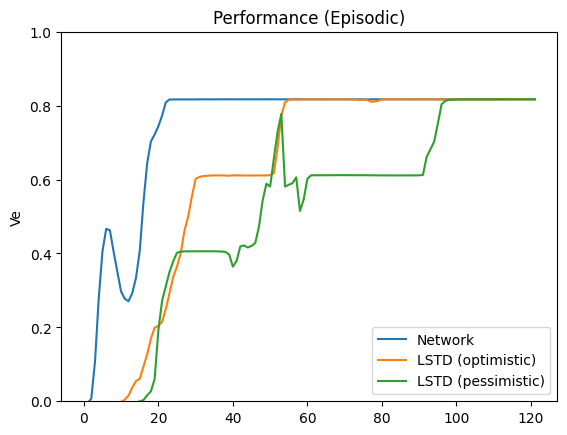

In [12]:
plt.plot((net_metrics['v_e'].mean(0))[:,0,0], label = 'Network')
plt.plot((lstd_metrics['v_e'].mean(0))[:,0,0], label = 'LSTD (optimistic)')
plt.plot((lstd_metrics_pess['v_e'].mean(0))[:,0,0], label = 'LSTD (pessimistic)')
# plt.plot(lstd_metrics['fast_i_value_error'].mean(0), label = 'LSTD Fast i_val MSE')
plt.legend()
plt.title('Performance (Episodic)')
plt.ylabel('Ve')
plt.ylim(top=1, bottom=0)
plt.savefig('figures/perf_opt_vs_pess_vs_net.pdf')
email_pdf('figures/perf_opt_vs_pess_vs_net.pdf')
# plt.yscale('log')

(0.0, 1.0)

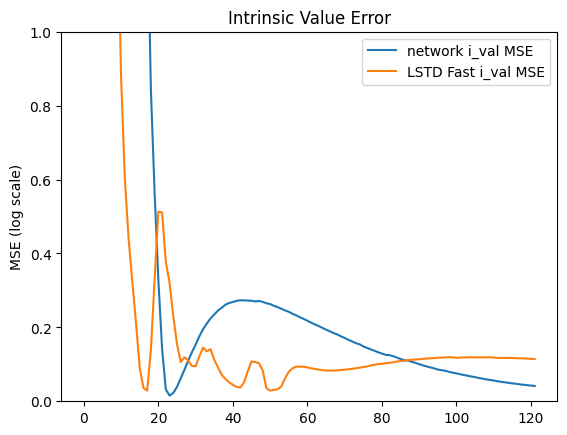

In [13]:
plt.plot(net_metrics['i_value_error'].mean(0), label = 'network i_val MSE')
plt.plot(lstd_metrics['fast_i_value_error'].mean(0), label = 'LSTD Fast i_val MSE')
plt.legend()
plt.title('Intrinsic Value Error')
plt.ylabel('MSE (log scale)')
plt.ylim(top=1, bottom=0)
# plt.yscale('log')

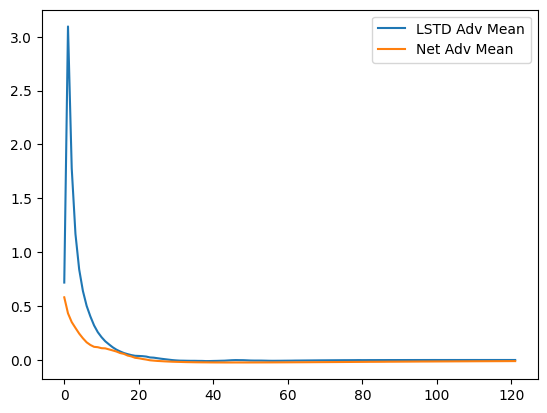

In [14]:
plt.plot(lstd_metrics['bonus_mean'].mean(0), label = 'LSTD Adv Mean')
plt.plot(net_metrics['bonus_mean'].mean(0), label = 'Net Adv Mean')
plt.legend()


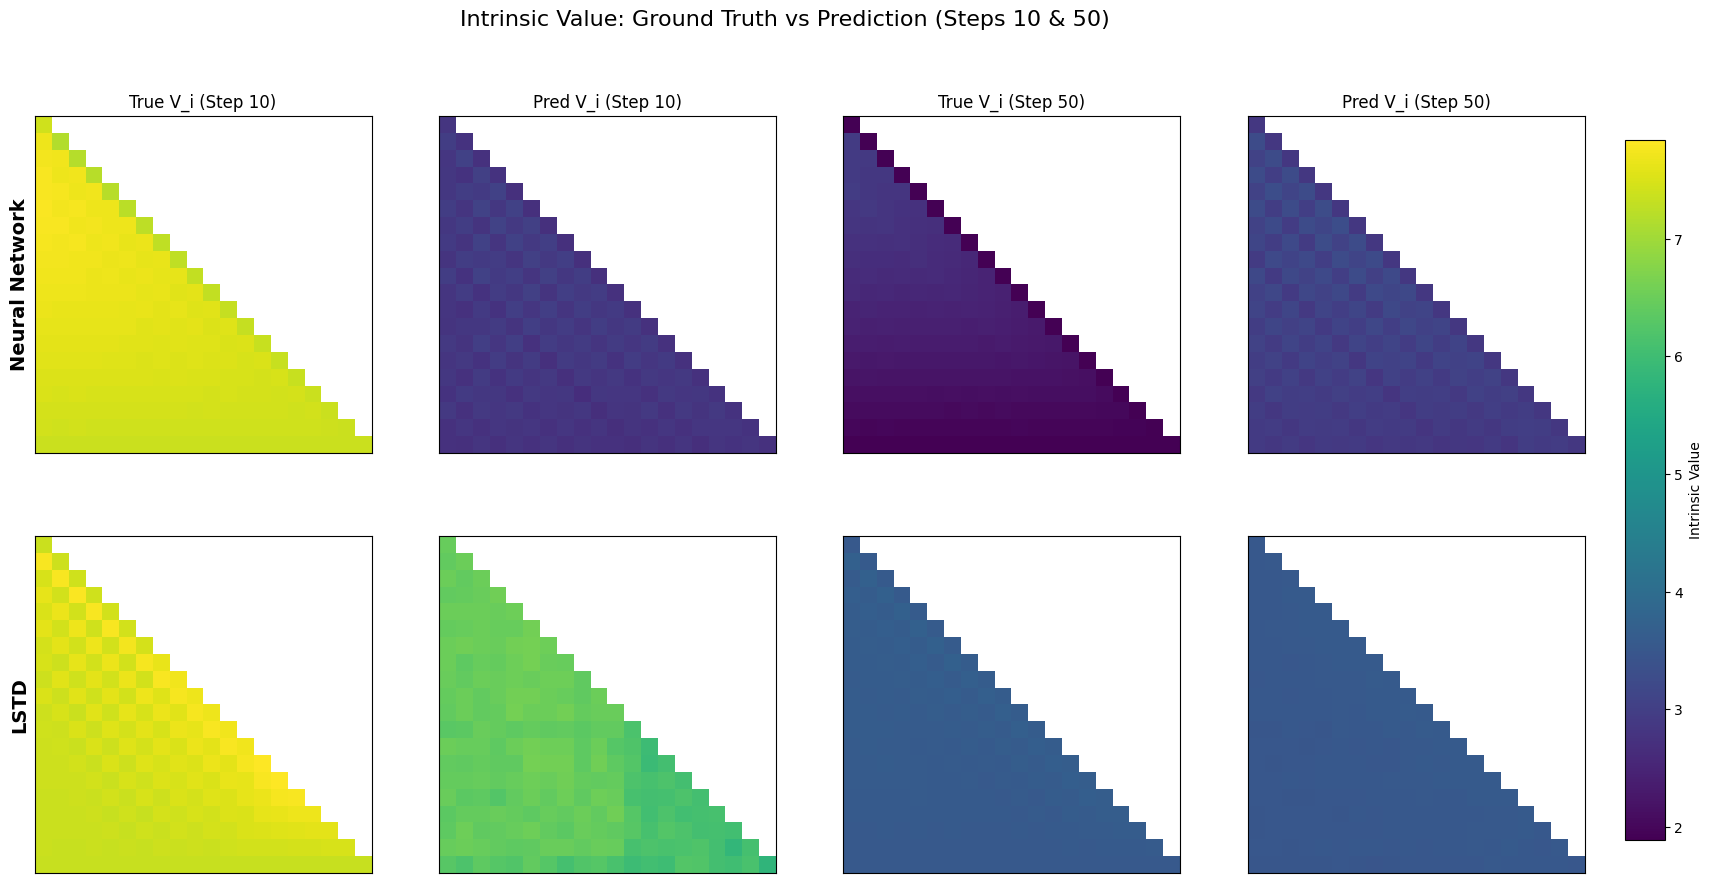

In [15]:

import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

N = lstd_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

# 1. Setup & Masking
N = net_config['DEEPSEA_SIZE']
reachable_mask = np.tril(np.ones((N, N)))

def get_masked_grid(metric_array, step_idx, seed_idx=0):
    """Extracts grid, applies mask, and sets non-reachable to NaN for plotting."""
    grid = metric_array[seed_idx, step_idx]
    # Apply mask: Keep reachable, set others to NaN
    masked_grid = np.where(reachable_mask == 1, grid, np.nan)
    return masked_grid

# 2. Extract Data for Plotting
# Steps to visualize
t1, t2 = 10, 50

# Row 1: Network Data
net_true_t1 = get_masked_grid(net_metrics['v_i'], t1)
net_pred_t1 = get_masked_grid(net_metrics['v_i_pred'], t1)
net_true_t2 = get_masked_grid(net_metrics['v_i'], t2)
net_pred_t2 = get_masked_grid(net_metrics['v_i_pred'], t2)

# Row 2: LSTD Data
lstd_true_t1 = get_masked_grid(lstd_metrics['v_i'], t1)
lstd_pred_t1 = get_masked_grid(lstd_metrics['fast_v_i_pred'], t1) # Using fast_v_i_pred
lstd_true_t2 = get_masked_grid(lstd_metrics['v_i'], t2)
lstd_pred_t2 = get_masked_grid(lstd_metrics['fast_v_i_pred'], t2)

# 3. Compute Global Limits for Common Color Scale
all_grids = [
    net_true_t1, net_pred_t1, net_true_t2, net_pred_t2,
    lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2
]
# Use nanmin/nanmax to ignore the masked regions
vmin = np.nanmin(all_grids)
vmax = np.nanmax(all_grids)

# 4. Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Neural Network
rows = ["Neural Network", "LSTD"]
data_matrix = [
    [net_true_t1, net_pred_t1, net_true_t2, net_pred_t2],
    [lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2]
]

titles = [
    f"True V_i (Step {t1})", f"Pred V_i (Step {t1})", 
    f"True V_i (Step {t2})", f"Pred V_i (Step {t2})"
]

for row_idx in range(2):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        grid = data_matrix[row_idx][col_idx]
        
        im = ax.imshow(grid, cmap='viridis', vmin=vmin, vmax=vmax)
        
        # Formatting
        if col_idx == 0:
            ax.set_ylabel(rows[row_idx], fontsize=14, fontweight='bold')
        
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=12)
            
        ax.set_xticks([])
        ax.set_yticks([])

# Add a single Colorbar for the whole figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Intrinsic Value')

plt.suptitle(f"Intrinsic Value: Ground Truth vs Prediction (Steps {t1} & {t2})", fontsize=16)
plt.show()

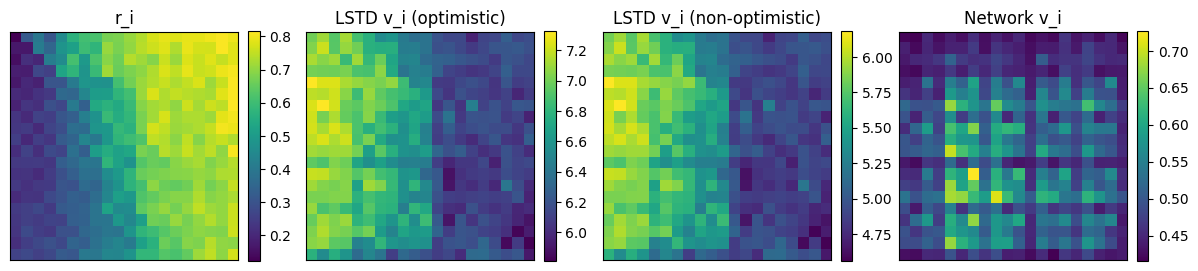

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

T = 0
# --- Plot 1 ---
im0 = axes[0].imshow(lstd_metrics['ri_grid'][0][T])
axes[0].set_title("r_i")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Plot 2 ---
im1 = axes[1].imshow(lstd_metrics['fast_v_i_pred'][0][T])
axes[1].set_title("LSTD v_i (optimistic)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(lstd_metrics_pess['fast_v_i_pred'][0][T])
axes[2].set_title("LSTD v_i (non-optimistic)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# --- Plot 3 ---
im3 = axes[3].imshow(net_metrics['v_i_pred'][0][T])
axes[3].set_title("Network v_i")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# Optional cleanup
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

plt.savefig('figures/grid_opt_vs_pess_vs_net.pdf')
# email_pdf('figures/grid_opt_vs_pess_vs_net.pdf')

In [17]:
email_pdf('figures/grid_opt_vs_pess_vs_net.pdf')

📁 Found figures/grid_opt_vs_pess_vs_net.pdf (1.2 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

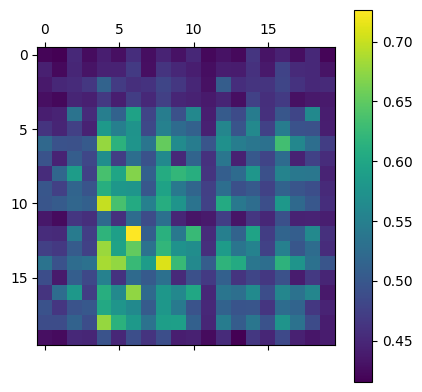

In [18]:
plt.matshow(net_metrics['v_i_pred'][0][T])
plt.colorbar(
    
)

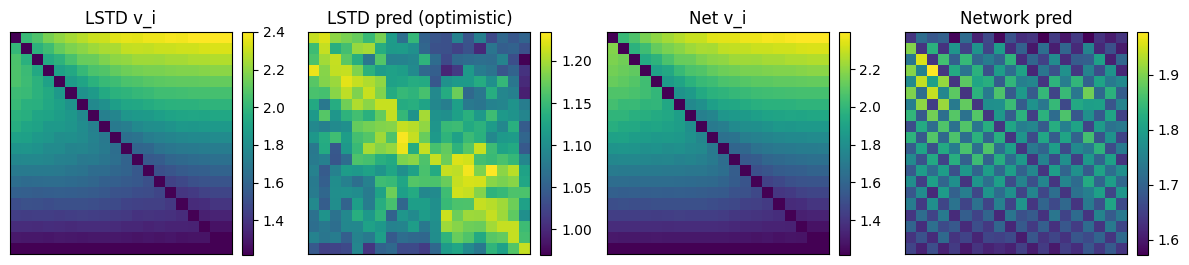

<Figure size 640x480 with 0 Axes>

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

T = 300

# --- Plot 1 ---
im0 = axes[0].imshow(lstd_metrics['v_i'][1][T])
axes[0].set_title("LSTD v_i")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Plot 2 ---
im1 = axes[1].imshow(lstd_metrics['fast_v_i_pred'][1][T])
axes[1].set_title("LSTD pred (optimistic)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(net_metrics['v_i'][1][T])
axes[2].set_title("Net v_i")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# --- Plot 3 ---
im3 = axes[3].imshow(net_metrics['v_i_pred'][1][T])
axes[3].set_title("Network pred")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# Optional cleanup
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

plt.savefig('figures/grid_opt_vs_pess_vs_net.pdf')

In [119]:
lstd_metrics['returned_episode_returns'][1][0:50]

Array([-4.2938236e-03, -4.9835211e-03, -5.8642584e-03, -6.3874517e-03,
       -6.2651373e-03, -6.5485844e-03, -6.7708744e-03, -2.0351568e-03,
        8.0102403e-04, -5.4577785e-04,  7.3183579e-03,  1.2005126e-02,
        2.7559325e-02,  8.9637816e-02,  1.9627233e-01,  3.0769604e-01,
        3.2686883e-01,  4.4688940e-01,  6.3088644e-01,  8.0875665e-01,
        9.6194494e-01,  9.8511958e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8877990e-01,
        9.8633969e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8999995e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01,  9.8511958e-01,  9.8999995e-01,
        9.8999995e-01,  9.8999995e-01], dtype=float32)

In [120]:
lstd_metrics['ri_grid'][1][10][21]

Array([0.10640599, 0.10515695, 0.11935134, 0.1078482 , 0.09913049,
       0.08106329, 0.10425426, 0.09034334, 0.11678824, 0.09395612,
       0.12966631, 0.11989375, 0.13698503, 0.13067634, 0.14990346,
       0.15450154, 0.16357163, 0.15533471, 0.18128127, 0.1850642 ],      dtype=float32)

In [121]:
lstd_metrics['fast_v_i_pred'][1][10][20]

Array([6.5930495, 6.632838 , 6.5175924, 6.57241  , 6.822557 , 6.670576 ,
       6.809317 , 6.6961117, 6.658608 , 6.7689104, 6.6327014, 6.588842 ,
       6.648999 , 6.744011 , 6.5671678, 6.4181237, 6.5818157, 6.6403046,
       6.539092 , 6.3400154], dtype=float32)

In [122]:
lstd_metrics['v_i'][1][10][18]

Array([8.31544 , 8.32699 , 8.317549, 8.310685, 8.294276, 8.312863,
       8.295176, 8.319728, 8.303725, 8.335888, 8.315318, 8.345526,
       8.338468, 8.357414, 8.354732, 8.371591, 8.365342, 8.389491,
       8.392127, 8.394734], dtype=float32)